# 8章 アドレスの問い合わせ

インターネット上ではMACアドレスやIPアドレスを用いた通信が行われています。
その一方で、私たちの日常生活では、これらのアドレスを意識する機会はほとんどありません。
このようなことが可能なのは、アドレスの問い合わせという仕組みがあるからです。
本章では、通信に先立ってMACアドレスやIPアドレスを問い合わせる仕組みについて学習します。

## ARPによるMACアドレス解決

### ARPとは

前章までの実装では、IPアドレスとMACアドレスの対応表であるARPテーブルを手書きで設定していました。
ただ、少し考えれば容易に想像がつく通り、このようなテーブルを手動設定するのは不便ですし、現実的ではありません。
ノード間の通信では基本的に、宛先IPアドレスを指定してパケットを送出しています。
その際、宛先MACアドレスをユーザが書くことはありませんし、パソコンやルータなどにテーブルを登録することもありません。
このようなことが可能なのは、MACアドレスを問い合わせるプロトコルがあるからです。

ARP（Address Resolution Protocol）は、IPアドレスからMACアドレスを調べるために用いられます。
ARPの動作はかなりシンプルです。
ネットワーク上のノード（`Node`や``Router`）が宛先IPアドレスに向けてパケットを送信したいが、対応するMACアドレスを知らない場合に、ARPが使用されます。
このプロセスは以下のステップで構成されます。

#### ARPリクエストのブロードキャスト：

送信元ノードは、宛先のIPアドレスを含むARPリクエストをネットワーク上の全てのデバイスにブロードキャストします。
このリクエストには、送信元のIPアドレスとMACアドレスも含まれます。

#### ARPリプライの受信：

ネットワーク上の各ノードは、受信したARPリクエストを確認し、リクエストに含まれる宛先IPアドレスが自身のものである、あるいはルーティングテーブルに登録されているかどうかを判断します。
宛先IPアドレスが自身のものであるノード、あるいは宛先IPアドレスへの経路を知っているルータは、送信元に対してARPリプライを送信します。
このリプライには、自身のMACアドレスが含まれます。

#### ARPテーブルの更新：

ARPリクエストの送信元ノードは、ARPリプライを受信すると、その情報を使用して自身のARPテーブルを更新します。
ARPテーブルは、IPアドレスと対応するMACアドレスのマッピング情報を保持するデータベースです。

#### データパケットの送信：

ARPテーブルが更新された後、送信元ノードは宛先IPアドレスに対応する宛先MACアドレスを使用して、データパケットを送信します。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 443, done.
remote: Total 443 (delta 0), reused 0 (delta 0), pack-reused 443
Receiving objects: 100% (443/443), 116.50 KiB | 840.00 KiB/s, done.
Resolving deltas: 100% (326/326), done.


### `ARPPacket`クラスの実装

`Packet`クラスをベースにして、`ARPPacket`クラスを実装します。
`ARPPacket`は、ARP専用のパケットです。
本クラスでは、ARPリクエストやリプライを生成するために必要な情報を`__init__`メソッドで受け取り、`Packet`クラスのコンストラクタを通じて基本的なパケット情報を設定します。
ARPに固有の情報は`payload`属性に格納され、送信元と宛先のMACアドレス、IPアドレス、そしてARP操作（リクエストまたはリプライ）が定義されます。


```
class ARPPacket(Packet):
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, operation, network_event_scheduler):
        # Packetクラスのコンストラクタを呼び出し、ARPパケットに必要な基本情報を設定します。
        # これには送信元と宛先のMACアドレス、IPアドレス、およびネットワークイベントスケジューラへの参照が含まれます。
        # ARPパケットでは、TTL（Time To Live）、フラグメントフラグ、フラグメントオフセットは使用されませんが、
        # Packetクラスの構造に合わせてダミーの値を設定します。
        super().__init__(
            source_mac=source_mac,
            destination_mac=destination_mac,
            source_ip=source_ip,
            destination_ip=destination_ip,
            ttl=1, fragment_flags={}, fragment_offset=0,  # ダミーのTTLとフラグメント情報
            header_size=28,  # ARPヘッダの標準的なサイズ
            payload_size=28,  # ARPパケットのペイロードサイズ
            network_event_scheduler=network_event_scheduler
        )
        # ARPパケットに特有の情報をペイロード属性に格納します。
        # これにはARP操作（リクエストまたはリプライ）、送信元と宛先のMACアドレス、およびIPアドレスが含まれます。
        self.payload = {
            "operation": operation,  # ARP操作（"request"または"reply"）
            "source_mac": source_mac,  # 送信元MACアドレス
            "destination_mac": destination_mac,  # 宛先MACアドレス
            "source_ip": source_ip,  # 送信元IPアドレス
            "destination_ip": destination_ip  # 宛先IPアドレス
        }

    def __str__(self):
        # ARPパケットの情報を人が読みやすい文字列形式で返します。
        # ここでは送信元MACアドレス、宛先MACアドレス、および操作タイプを表示します。
        return f'ARPPacket(送信元MAC: {self.mac_header["source_mac"]}, 宛先MAC: {self.mac_header["destination_mac"]}, 操作: {self.payload["operation"]})'
```

### `Node`クラスのアップデート

ARPパケットを送受信してMACアドレスを問い合わせるように、`Node`クラスをアップデートします。

#### ARPリクエストの送信

`send_packet`メソッドにおいて、宛先IPアドレスに対応するMACアドレスを取得しようとします。
宛先MACアドレスがARPテーブルに存在しない場合（Noneが返された場合）、デバイスは`send_arp_request`メソッドを呼び出して宛先IPアドレス宛にARPリクエストを送信し、そのIPアドレスに対応するMACアドレスの取得を試みます。
同時に、送信しようとしているデータとヘッダーサイズを含むタプルを、宛先IPアドレスをキーとする待機リストに追加します。
後でARPリプライが受信された際に、これらの待機中のパケットを送信します。

```
def send_packet(self, destination_ip, data, header_size):
    # 宛先IPアドレスに対応するMACアドレスを取得します。
    destination_mac = self.get_mac_address_from_ip(destination_ip)

    if destination_mac is None:
        # 宛先MACアドレスが未知の場合、ARPリクエストを送信してMACアドレスを取得しようとします。
        # また、宛先IPアドレスに関連する待機リストに、現在送信しようとしているパケットの情報を追加します。
        # これにより、ARPリプライが受信された後に、これらのパケットを送信できるようになります。
        self.send_arp_request(destination_ip)
        if destination_ip not in self.waiting_for_arp_reply:
            self.waiting_for_arp_reply[destination_ip] = []
        self.waiting_for_arp_reply[destination_ip].append((data, header_size))
    else:
        # 宛先MACアドレスが既知の場合、直接パケットを送信します。
        # _send_packet_dataメソッドを呼び出して、宛先IP、宛先MACアドレス、データ、ヘッダーサイズを指定してパケットを送信します。
        self._send_packet_data(destination_ip, destination_mac, data, header_size)

def send_arp_request(self, ip_address):
    # ARPリクエストパケットを作成するための処理です。
    # ARPPacketクラスのインスタンスを作成して、ARPリクエストパケットを生成します。
    arp_request_packet = ARPPacket(
        source_mac=self.mac_address,  # このデバイス（送信元）のMACアドレス
        destination_mac="FF:FF:FF:FF:FF:FF",  # 宛先MACアドレスとしてブロードキャストアドレスを使用
        source_ip=self.ip_address,  # このデバイス（送信元）のIPアドレス
        destination_ip=ip_address,  # 問い合わせたいデバイスのIPアドレス
        operation="request",  # ARP操作として「リクエスト」を指定
        network_event_scheduler=self.network_event_scheduler  # ネットワークイベントのスケジューラ
    )
    # 生成したARPリクエストパケットに関する情報をログに記録します。
    self.network_event_scheduler.log_packet_info(arp_request_packet, "ARP request", self.node_id)
    # 実際にARPリクエストパケットを送信するための内部メソッドを呼び出します。
    self._send_packet(arp_request_packet)
```

#### ARPリクエストの受信

受信したARPリクエストに対して応答するために使用されます。
リクエストを送信したノードが要求しているIPアドレスを持つノードが、自身のMACアドレスをリクエスト送信元に知らせるためにARPリプライを送ります。
ARPPacketのインスタンス生成時に、送信元と宛先のMACアドレス、IPアドレスを適切に設定して、ARPリプライを表現します。
operation="reply"により、このパケットがARPリプライであることを示しています。
リプライは、リクエストの送信元に直接送り返されるため、リクエストパケットから送信元のMACアドレスとIPアドレスを宛先として使用します。
パケットの作成と送信ログの記録の後、_send_packetメソッドを使用して実際にネットワーク上にパケットを送信します。

```
def _send_arp_reply(self, request_packet):
    # ARPリプライパケットを作成します。
    # ARPPacketクラスのインスタンスを作成して、ARPリプライパケットを生成します。
    arp_reply_packet = ARPPacket(
        source_mac=self.mac_address,  # 送信元MACアドレスとして、このデバイスのMACアドレスを使用します。
        destination_mac=request_packet.header["source_mac"],  # 宛先MACアドレスとして、ARPリクエストを送信したデバイスのMACアドレスを使用します。
        source_ip=self.ip_address,  # 送信元IPアドレスとして、このデバイスのIPアドレスを使用します。
        destination_ip=request_packet.header["source_ip"],  # 宛先IPアドレスとして、ARPリクエストを送信したデバイスのIPアドレスを使用します。
        operation="reply",  # 操作として"reply"を指定して、これがARPリプライであることを示します。
        network_event_scheduler=self.network_event_scheduler  # ネットワークイベントスケジューラへの参照。
    )
    # 生成したARPリプライパケットに関する情報をログに記録します。
    self.network_event_scheduler.log_packet_info(arp_reply_packet, "ARP reply", self.node_id)
    # 実際にARPリプライパケットを送信するための内部メソッドを呼び出します。
    self._send_packet(arp_reply_packet)
```

#### ARPリプライの受信

ARPリプライを受信した際に、受信したARPリプライに含まれる宛先MACアドレスを使用して、一時保留されていたパケットの送信を再開します。
`self.waiting_for_arp_reply`辞書は、宛先IPアドレスをキーとし、その宛先へ送信しようとしていたがMACアドレスが不明で待機中のパケットのリストを値として保持しています。
ARPリプライが受信されると、その宛先IPアドレスに対応する待機中のパケットがあるかどうかを確認し、存在する場合はそれらのパケットをすべて送信します。

```
def on_arp_reply_received(self, destination_ip, destination_mac):
    # ARPリプライを受信した場合の処理を定義します。
    # self.waiting_for_arp_reply は、宛先IPアドレスごとに待機中のパケットを格納している辞書です。

    if destination_ip in self.waiting_for_arp_reply:
        # 宛先IPアドレスがself.waiting_for_arp_replyに存在する場合、
        # つまり、この宛先IPアドレス宛に送信しようとしていたが、MACアドレスが不明で保留していたパケットがある場合

        # 待機中のパケットのリストを反復処理します。
        for data, header_size in self.waiting_for_arp_reply[destination_ip]:
            # 各パケットに対して、_send_packet_dataメソッドを呼び出して送信を試みます。
            # この時点で、宛先MACアドレスはARPリプライから得られたMACアドレスを使用します。
            self._send_packet_data(destination_ip, destination_mac, data, header_size)

        # すべての待機中のパケットが処理された後、その宛先IPアドレスに関連するエントリを辞書から削除します。
        del self.waiting_for_arp_reply[destination_ip]
```

### `Router`クラスのアップデート

`Router`クラスについても、ARPに対応するようにアップデートを行います。
基本的には`Node`クラスと同様ですが、ルーティングテーブルを参照する点、MACヘッダの付け替えを行う点が異なります。

`forward_packet`メソッドでは、パケットの宛先IPアドレスに基づいて適切な転送処理を行います。これにはマルチキャストアドレス、特定のリンクを通じたユニキャスト転送、デフォルトルートを使用した転送が含まれます。
`process_and_enqueue_packet`メソッドでは、宛先MACアドレスが既知の場合は直接パケットを転送し、不明の場合はARPリクエストを送信して待機リストにパケットを追加します。
`send_arp_request`メソッドでは、指定された宛先IPアドレスに対してARPリクエストを送信するための処理を行い、ネットワーク上で宛先のMACアドレスを問い合わせます。

```
def forward_packet(self, packet):
    # パケットの宛先IPアドレスを取得します。
    destination_ip = packet.header["destination_ip"]
    # 宛先IPアドレスに基づいてルーティングテーブルから次のホップとリンクを取得します。
    next_hop, link = self.get_route(destination_ip)

    # 宛先IPがマルチキャストアドレスの場合、すべてのインターフェースを通じてパケットを転送します。
    if destination_ip == "224.0.0.5":
        for link in self.interfaces.keys():
            self.process_and_enqueue_packet(packet, link)
    elif link:  # ユニキャストの場合、特定のリンクを通じてパケットを転送します。
        self.process_and_enqueue_packet(packet, link)
    elif self.default_route:  # デフォルトルートが設定されている場合、そのルートを使用してパケットを転送します。
        self.process_and_enqueue_packet(packet, self.default_route)
    else:
        # 宛先へのルートが見つからない場合、パケットをドロップします。
        self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)

def process_and_enqueue_packet(self, packet, link):
    # パケットを転送するための処理を定義します。
    source_mac = self.get_mac_address(link)  # 送信インターフェースのMACアドレスを取得します。
    destination_ip = packet.header["destination_ip"]
    # 宛先IPアドレスに対応するMACアドレスをARPテーブルから取得します。
    destination_mac = self.get_mac_address_from_ip(destination_ip)
    if destination_mac is None:
        # 宛先MACアドレスが不明の場合、ARPリクエストを送信し、パケットを待機リストに追加します。
        self.send_arp_request(link, destination_ip)
        if destination_ip not in self.waiting_for_arp_reply:
            self.waiting_for_arp_reply[destination_ip] = []
        self.waiting_for_arp_reply[destination_ip].append(packet)
    else:
        # 宛先MACアドレスが既知の場合、MACヘッダを追加してパケットをリンクのキューに追加します。
        packet.add_mac_header(source_mac, destination_mac)
        self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
        link.enqueue_packet(packet, self)

def send_arp_request(self, link, ip_address):
    # 宛先IPアドレスに対するARPリクエストを送信する処理を定義します。
    arp_request_packet = ARPPacket(
        source_mac=self.get_mac_address(link),  # 送信インタフェースのMACアドレス
        destination_mac="FF:FF:FF:FF:FF:FF",  # ブロードキャストアドレス
        source_ip=self.get_ip_address(link),  # 送信インタフェースのIPアドレス
        destination_ip=ip_address,
        operation="request",
        network_event_scheduler=self.network_event_scheduler
    )
    # ARPリクエストに関する情報をログに記録し、リンクのキューにARPリクエストパケットを追加します。
    self.network_event_scheduler.log_packet_info(arp_request_packet, "ARP request", self.node_id)
    link.enqueue_packet(arp_request_packet, self)
```


### ARPの動作確認

さて、それではARPの動作を確認してみましょう。
`ARPPacket`送受信時にログメッセージを表示できるので、各ノードでの処理の様子を確認できます。

また、以下のシナリオでシミュレーションを行ってみましょう。
複数のノードをスイッチを介して接続し、`ARPPacket`がブロードキャストされ、宛先IPアドレスに一致したノードがリプライを返します。
その結果として、エンドノード間でデータパケットを送受信可能になります。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


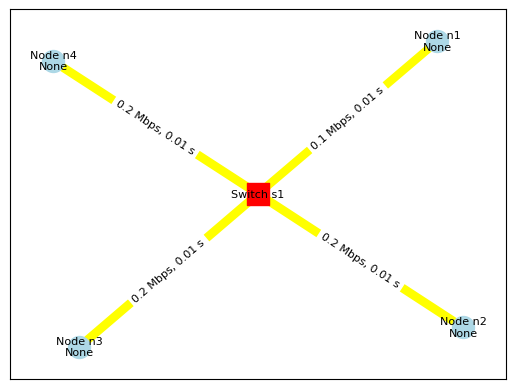

Time: 1.0 Node: n1, Event: ARP request, Packet: b9859d58-e604-46a1-9366-bf9faae8d4b7, Src: 192.168.1.1/24, Dst: 192.168.1.2/24
Time: 1.0 Node: n2, Event: ARP request, Packet: 8590722a-64a3-4a30-96d5-619fd0a70c68, Src: 192.168.1.2/24, Dst: 192.168.1.3/24
Time: 1.0 Node: n3, Event: ARP request, Packet: 28b73cf3-6211-4417-b924-7d5c0c6292c9, Src: 192.168.1.3/24, Dst: 192.168.1.4/24
Time: 1.0 Node: n4, Event: ARP request, Packet: ed7cda22-cbc0-4d56-90fa-d3b888fd1c31, Src: 192.168.1.4/24, Dst: 192.168.1.1/24
Time: 1.01 Node: s1, Event: received, Packet: b9859d58-e604-46a1-9366-bf9faae8d4b7, Src: 192.168.1.1/24, Dst: 192.168.1.2/24
Time: 1.01 Node: s1, Event: broadcast, Packet: b9859d58-e604-46a1-9366-bf9faae8d4b7, Src: 192.168.1.1/24, Dst: 192.168.1.2/24
Time: 1.01 Node: s1, Event: broadcast, Packet: b9859d58-e604-46a1-9366-bf9faae8d4b7, Src: 192.168.1.1/24, Dst: 192.168.1.2/24
Time: 1.01 Node: s1, Event: broadcast, Packet: b9859d58-e604-46a1-9366-bf9faae8d4b7, Src: 192.168.1.1/24, Dst: 192.

In [2]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec8a.NetworkEventScheduler import NetworkEventScheduler
from sec8a.Node import Node
from sec8a.Switch import Switch
from sec8a.Router import Router
from sec8a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.1.2/24", network_event_scheduler=nes)
node3 = Node(node_id="n3", ip_address="192.168.1.3/24", network_event_scheduler=nes)
node4 = Node(node_id="n4", ip_address="192.168.1.4/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.11/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(node2, switch1, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(node3, switch1, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(node4, switch1, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_ip="192.168.1.2/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node2.set_traffic(destination_ip="192.168.1.3/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node3.set_traffic(destination_ip="192.168.1.4/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node4.set_traffic(destination_ip="192.168.1.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node2.print_arp_table()
node3.print_arp_table()
node4.print_arp_table()
switch1.print_forwarding_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


### ルータにおけるARPの動作確認

さらに、ルータを用いた際のARPの動作についても確認してみましょう。
以下のシナリオでシミュレーションを実行し、ログを確認します。
ARPによるMACアドレスの問い合わせが順次行われることで、宛先ノードまでパケットが到達するようになります。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


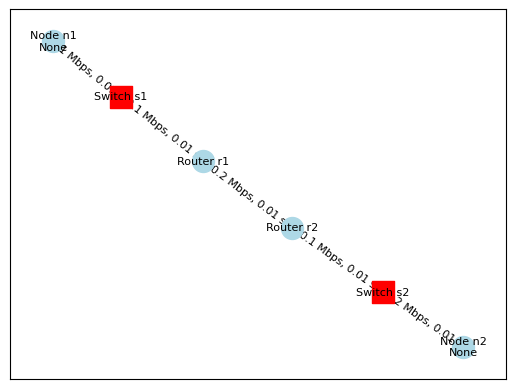

Time: 0.01 Node: r1, Event: dropped BPDU, Packet: 70e29329-6517-444b-b4bd-8fdeb62907e0, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: r2, Event: dropped BPDU, Packet: b1fda77f-e585-44ad-92f3-e90b21610f1f, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r2, Event: dropped BPDU, Packet: b3a13f52-069c-4b30-b6ed-74fd3a08ec67, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.08579550106461808 Node: s1, Event: received, Packet: 250a16cf-23b7-41ed-baa2-8a5550b601a8, Src: 192.168.1.254, Dst: 224.0.0.5
Time: 0.09180326426081206 Node: s2, Event: received, Packet: a50fe9fd-18b8-4ffd-99b7-3eff34db5c34, Src: 192.168.2.254, Dst: 224.0.0.5
Time: 0.3790543594503416 Node: s2, Event: received, Packet: 89cec62c-04bc-44b8-8dda-9147c3f3b7a4, Src: 192.168.2.254/24, Dst: 224.0.0.5
Time: 0.3890543594503416 Node: s1, Event: received, Packet: 3c481676-e6dc-422c-9af1-140680df2e62, Src: 10.1.1.2/24, Dst: 224.0.0.5
Time: 0.4418378441033679 Node: s1, Event: received, Packet: 28832991-ff95-4aed-8e40-0f999a5758c7, Sr

In [3]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec8a.NetworkEventScheduler import NetworkEventScheduler
from sec8a.Node import Node
from sec8a.Switch import Switch
from sec8a.Router import Router
from sec8a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
# スイッチにも管理用のIPアドレスが設定されることが一般的です（実世界では遠隔ログインなどに利用します）
switch1 = Switch(node_id="s1", ip_address="192.168.1.11/24", network_event_scheduler=nes)
switch2 = Switch(node_id="s2", ip_address="192.168.2.11/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.1.1.1/24"], network_event_scheduler=nes)
router2 = Router(node_id="r2", ip_addresses=["192.168.2.254/24", "10.1.1.2/24"], network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(router1, router2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(router2, switch2, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(switch2, node2, bandwidth=200000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_ip="192.168.2.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
node2.set_traffic(destination_ip="192.168.1.1/24", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node2.print_arp_table()

switch1.print_forwarding_table()
switch2.print_forwarding_table()

router1.print_arp_table()
router1.print_routing_table()

router2.print_arp_table()
router2.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)



## DNSによるIPアドレスの問い合わせ

### DNSとは

ここまでに学習してきた通り、インターネットにおいて住所に当たる情報はIPアドレスです。
すべての通信で、IPアドレスを用いてパケットが送受信されています。
それにも関わらず、私たちが普段インターネットを利用するとき、IPアドレスを直接指定するようなことはありません。
これはDNS（Domain Name System）と呼ばれる仕組みのおかげです。

DNSは、インターネット上でドメイン名（例: www.example.com）をIPアドレス（例: 192.0.2.1）に変換するためのシステムです。
インターネット上のノードはIPアドレスによって識別されますが、単なる数字の羅列であるため、人間にとっては扱い難いです。
DNSは、人間が覚えやすいドメイン名を使って、コンピュータが理解できるIPアドレスへと変換する役割を担っています。

### DNSの仕組み

- クエリの送信: ユーザーがブラウザにURLを入力してWebサイトにアクセスしようとすると、コンピュータはそのドメイン名に対応するIPアドレスを知る必要があります。そこで、コンピュータはDNSサーバに対して「このドメイン名のIPアドレスは何ですか？」と問い合わせるDNSクエリを送信します。

- 名前解決: DNSサーバは、受け取ったクエリに基づいてドメイン名をIPアドレスに変換します。この過程では、複数のDNSサーバが関与することがあり、最終的に目的のドメイン名に対応するIPアドレスを見つけ出します。

- レスポンスの受信: DNSサーバは、見つけたIPアドレスをクエリを送信したコンピュータに返します。コンピュータはこのIPアドレスを使用して、実際にWebサーバに接続し、Webサイトのデータを取得します。

### DNSの重要性

- ユーザビリティの向上: DNSによって、人間が覚えやすいドメイン名でインターネット上のリソースにアクセスできるようになります。

- 動的なIPアドレスの管理: WebサーバなどのリソースのIPアドレスは変更されることがありますが、DNSを使用することで、ドメイン名はそのままにIPアドレスだけを更新することができます。

- 分散型のインターネット: DNSは世界中に分散して存在する多数のサーバによって構成されています。この分散型の構造は、インターネットの耐障害性を高め、特定の地域での問題が全世界に影響を及ぼすのを防ぎます。



### `DNSPacket`クラスの実装

`Packet`クラスをベースとして、DNSで用いる`DNSPacket`クラスを実装します。
このクラスは、ドメイン名の問い合わせ（クエリ）やその問い合わせに対する回答（レスポンス）を表現するために設計されています。

```
class DNSPacket(Packet):
    # DNSPacketクラスのコンストラクタです。
    # このクラスは、DNSクエリやレスポンスを扱うためのPacketクラスのサブクラスです。
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, query_domain, query_type, network_event_scheduler):
        # スーパークラス（Packet）のコンストラクタを呼び出して、基本的なパケット情報を初期化します。
        # これには、送信元と宛先のMACアドレス、IPアドレス、TTL（Time To Live）、フラグメント情報などが含まれます。
        super().__init__(
            source_mac=source_mac,
            destination_mac=destination_mac,
            source_ip=source_ip,
            destination_ip=destination_ip,
            ttl=64,  # DNSパケットのTTL（Time To Live）。この値は通常のIPパケットと同様に設定されます。
            fragment_flags={},  # フラグメント関連のフラグ。DNSパケットでは通常フラグメントされないため空の辞書を設定。
            fragment_offset=0,  # フラグメントのオフセット。DNSパケットでは使用されないため0を設定。
            header_size=0,  # DNSヘッダのサイズ。DNSパケットではヘッダサイズが固定ではないため、ここでは0を設定。
            payload_size=0,  # ペイロードのサイズ。DNSクエリの内容によって異なるため、ここでは0を設定。
            network_event_scheduler=network_event_scheduler  # ネットワークイベントスケジューラへの参照。
        )
        self.query_domain = query_domain  # DNSクエリで問い合わせるドメイン名。
        self.query_type = query_type  # DNSクエリのタイプ。例えば、'A'（IPv4アドレス）、'AAAA'（IPv6アドレス）、'MX'（メール交換サーバ）など。
        # DNSクエリやレスポンスの詳細情報を格納するプレースホルダ。実際のクエリやレスポンスの内容に応じて情報が格納されます。
        self.dns_data = {}

    # DNSパケットの文字列表現を返す特殊メソッドです。
    def __str__(self):
        # MACヘッダから送信元と宛先のMACアドレスを取得し、不明な場合は"不明"と表示します。
        source_mac = self.mac_header.get("source_mac", "不明")
        destination_mac = self.mac_header.get("destination_mac", "不明")
        # DNSパケットの主要な情報を含む文字列を返します。
        return f'DNSPacket(送信元MAC: {source_mac}, 宛先MAC: {destination_mac}, 送信元IP: {self.ip_header["source_ip"]}, 宛先IP: {self.ip_header["destination_ip"]}, Query Domain: {self.query_domain}, Query Type: {self.query_type})'
```

### `Node`クラスのアップデート

#### `start_traffic`メソッド

特定の宛先URLに向けてトラフィックを生成し、そのトラフィックを指定された時間に開始するためのメソッドを用意します。
最初に、`attempt_to_start_traffic`内部関数を定義し、そこで宛先URLから宛先IPアドレスを解決しようと試みます。これは`resolve_destination_ip`メソッドを使って行われます。
もし宛先IPアドレスがDNSレコードによってまだ解決されていなければ、`send_dns_query_and_set_traffic`メソッドを使ってDNSクエリを送信し、DNSレスポンスが受信された後にトラフィックを開始する処理をスケジュールします。

```
def start_traffic(self, destination_url, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0):
    # トラフィック生成を試みる内部関数
    def attempt_to_start_traffic():
        # 宛先URLから宛先IPアドレスを解決しようと試みます。
        destination_ip = self.resolve_destination_ip(destination_url)
        if destination_ip is None:
            # 宛先IPアドレスがDNSレコードによって解決できない場合、DNSクエリを送信します。
            # DNSレスポンスを受信した後にトラフィック生成を開始するために、
            # 適切な処理をスケジュールします。
            self.send_dns_query_and_set_traffic(destination_url, bitrate, start_time, duration, header_size, payload_size, burstiness)
        else:
            # 宛先IPアドレスが既に解決されている場合、直接トラフィック生成を開始します。
            self.set_traffic(destination_ip, bitrate, start_time, duration, header_size, payload_size, burstiness)
    
    # 指定された開始時間に、宛先URLに向けてトラフィック生成を試みる処理をスケジュールします。
    self.network_event_scheduler.schedule_event(start_time, attempt_to_start_traffic)
```

#### DNSクエリの送信

- 宛先IPアドレスの解決

```
def resolve_destination_ip(self, destination_url):
    # このメソッドは、ノードが内部に持つURLからIPアドレスへのマッピング（url_to_ip_mapping）を使用して、
    # 与えられた宛先URLに対応するIPアドレスを検索します。
    # 対応するIPアドレスが見つかった場合はそのアドレスを返し、
    # 見つからない場合はNoneを返して、DNSクエリが必要であることを示します。
    return self.url_to_ip_mapping.get(destination_url, None)
```

- DNSクエリの送信とトラフィックのスケジュール

```
def send_dns_query_and_set_traffic(self, destination_url, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0):
    # このメソッドは、宛先URLのIPアドレスがまだ解決されていない場合に呼び出されます。
    # DNSクエリの結果を待っている間にトラフィック生成のパラメータを記録し、
    # DNSレスポンスが受信された後にこれらのパラメータを使用してトラフィックを開始します。
    if destination_url not in self.waiting_for_dns_reply:
        self.waiting_for_dns_reply[destination_url] = []
    self.waiting_for_dns_reply[destination_url].append((bitrate, start_time, duration, header_size, payload_size, burstiness))
    
    # DNSクエリの送信処理を行います。
    self.send_dns_query(destination_url)
```

- DNSクエリの生成と送信

```
def send_dns_query(self, destination_url):
    # このメソッドは、宛先URLに対するDNSクエリを生成し、ネットワークを介して送信します。
    dns_query_packet = DNSPacket(
        source_mac=self.mac_address,  # このノードのMACアドレスを送信元MACアドレスとして設定。
        destination_mac="FF:FF:FF:FF:FF:FF",  # DNSクエリはブロードキャストするため、宛先MACアドレスはブロードキャストアドレスを使用。
        source_ip=self.ip_address,  # このノードのIPアドレスを送信元IPアドレスとして設定。
        destination_ip=self.dns_server_ip,  # DNSサーバのIPアドレスを宛先IPアドレスとして設定。
        query_domain=destination_url,  # 解決したい宛先URLをクエリドメインとして設定。
        query_type="A",  # クエリタイプとして"A"（IPv4アドレスを問い合わせる）を指定。
        network_event_scheduler=self.network_event_scheduler  # ネットワークイベントスケジューラへの参照。
    )
    self.network_event_scheduler.log_packet_info(dns_query_packet, "DNS query", self.node_id)  # DNSクエリの情報をログに記録。
    self._send_packet(dns_query_packet)  # 生成したDNSクエリパケットをネットワークを介して送信。
```

#### DNSレスポンス受信時の処理

- DNSパケットの受信と処理

```
def receive_packet(self, packet, received_link):
    # 省略された部分には、他の種類のパケットを処理するコードが含まれます。

    # 受信したパケットがDNSPacketのインスタンスであるかどうかを確認します。
    if isinstance(packet, DNSPacket):
        # パケットがDNSレスポンスであることをログに記録します。
        self.network_event_scheduler.log_packet_info(packet, "DNS packet received", self.node_id)                
        # パケットからドメイン名と解決されたIPアドレスを取得します。
        if packet.query_domain and "resolved_ip" in packet.dns_data:
            # DNSレスポンスから得られた情報を使用して後続の処理を行います。
            self.on_dns_response_received(packet.query_domain, packet.dns_data["resolved_ip"])
            return
```

- DNSレスポンスの処理とトラフィック生成のスケジュール

```
def on_dns_response_received(self, query_domain, resolved_ip):
    # DNSレスポンスを受信した際の処理を実行します。
    # 解決されたIPアドレスをDNSテーブルに追加します。
    self.add_dns_record(query_domain, resolved_ip)
    # DNSクエリの結果を待っていたトラフィック生成のパラメータがあれば、それを使用してトラフィックを開始します。
    if query_domain in self.waiting_for_dns_reply:
        for parameters in self.waiting_for_dns_reply[query_domain]:
            bitrate, start_time, duration, header_size, payload_size, burstiness = parameters
            # 解決されたIPアドレスを使用してトラフィック生成を開始します。
            self.set_traffic(resolved_ip, bitrate, start_time, duration, header_size, payload_size, burstiness)
        # 処理が完了したら、該当するドメイン名のエントリを削除します。
        del self.waiting_for_dns_reply[query_domain]
```

また、`Router`クラスでも同様のアップデートを行います。

### `DNSServer`クラスの実装

このクラスは、DNSサーバの機能をシミュレーションするために使用され、ドメイン名からIPアドレスへの変換（名前解決）を管理します。

#### クラスの定義

```
class DNSServer:
    # DNSServerクラスのコンストラクタです。
    # このクラスは、DNSサーバの機能を表現するために設計されています。
    def __init__(self, node_id, ip_address, network_event_scheduler, mac_address=None):
        # DNSサーバの一意の識別子。
        self.node_id = node_id
        # DNSサーバが接続されているリンクのリスト。
        self.links = []
        # MACアドレスが指定されていない場合、ランダムなMACアドレスを生成します。
        # 指定されている場合は、そのMACアドレスを使用します。
        if mac_address is None:
            self.mac_address = self.generate_mac_address()  # ランダムなMACアドレスを生成するメソッド。
        else:
            self.mac_address = mac_address  # 指定されたMACアドレスを使用。
        # DNSサーバのIPアドレス。
        self.ip_address = ip_address
        # ネットワークイベントを管理するスケジューラ。
        self.network_event_scheduler = network_event_scheduler
        # ドメイン名からIPアドレスへのマッピングを保持する辞書。
        # キーとしてドメイン名、値として対応するIPアドレスを格納します。
        self.dns_records = {}
        # ネットワークイベントスケジューラにこのDNSサーバを追加します。
        # これにより、ネットワーク上でのイベント（例えば、DNSクエリの受信）を処理できるようになります。
        label = f'DNSServer {node_id}'  # ノードのラベルを設定。
        self.network_event_scheduler.add_node(node_id, label, ip_addresses=[ip_address])
```

#### パケット受信時の処理

このメソッドでは、DNSServerが受信したパケットの種類に応じて適切な処理を行います。具体的には、ARPパケットがリクエストであればARPリプライを、DNSパケットがクエリであればDNSレスポンスを生成し送信します。それ以外のパケットや、宛先が自身ではないパケットはドロップされます。

```
def receive_packet(self, packet, received_link):
    # パケットが途中で失われた（ロスト）場合、その情報をログに記録します。
    if packet.arrival_time == -1:
        self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)
        return

    # パケットの宛先MACアドレスがブロードキャストアドレスまたはDNSサーバ自身のMACアドレスの場合のみ処理を続けます。
    if packet.header["destination_mac"] == "FF:FF:FF:FF:FF:FF" or packet.header["destination_mac"] == self.mac_address:
        # 受信したパケットがARPパケットの場合の処理
        if isinstance(packet, ARPPacket):
            # 受信したARPパケットがリクエストで、かつ宛先IPアドレスがこのサーバのIPアドレスの場合、ARPリプライを送信します。
            if packet.payload.get("operation") == "request" and packet.payload["destination_ip"] == self.ip_address:
                self._send_arp_reply(packet)

        # 受信したパケットがDNSパケットの場合の処理
        elif isinstance(packet, DNSPacket):
            # DNSパケットの宛先IPアドレスがこのサーバのIPアドレスの場合、DNSクエリの処理を行います。
            if packet.header["destination_ip"] == self.ip_address:
                self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
                packet.set_arrived(self.network_event_scheduler.current_time)

                # DNSクエリを受信したことをログに記録し、DNSクエリの処理を行います。
                self.network_event_scheduler.log_packet_info(packet, "DNS query received", self.node_id)
                dns_response_packet = self.handle_dns_query(packet)
                # DNSレスポンスパケットの送信前に、その情報をログに記録します。
                self.network_event_scheduler.log_packet_info(dns_response_packet, "DNS response", self.node_id)
                # 処理したクエリに対するレスポンスとして、DNSレスポンスパケットを送信します。
                self._send_packet(dns_response_packet)
        else:
            # その他のパケットで、宛先IPがこのノードではない場合、パケットをドロップ（破棄）し、その情報をログに記録します。
            self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)
```

#### DNSクエリパケットの処理

このメソッドは、DNSサーバがDNSクエリを受け取った際に、そのクエリに含まれるドメイン名が自身の管理するDNSレコード内に存在するかを確認します。存在する場合は、そのドメイン名に対応するIPアドレスを含むDNSレスポンスパケットを生成し、クエリを送信したクライアントに返します。クエリされたドメイン名がDNSレコードに存在しない場合は、何もせずにNoneを返し、クライアント側にドメイン名が見つからなかったことを示します。

```
def handle_dns_query(self, dns_packet):
    # DNSクエリパケットからクエリされたドメイン名を取得します。
    query_domain = dns_packet.query_domain
    
    # DNSレコード辞書からクエリされたドメイン名に対応するIPアドレスを検索します。
    if query_domain in self.dns_records:
        # クエリされたドメイン名がDNSレコードに存在する場合、
        # そのドメイン名に対応するIPアドレスをresolved_ip変数に格納します。
        resolved_ip = self.dns_records[query_domain]
        
        # DNSレスポンスパケットを生成します。このレスポンスパケットには、
        # 解決されたIPアドレスなどの情報が含まれます。
        dns_response_packet = DNSPacket(
            source_mac=self.mac_address,  # DNSサーバのMACアドレス
            destination_mac=dns_packet.header["source_mac"],  # クエリを送信したクライアントのMACアドレス
            source_ip=self.ip_address,  # DNSサーバのIPアドレス
            destination_ip=dns_packet.header["source_ip"],  # クエリを送信したクライアントのIPアドレス
            query_domain=query_domain,  # クエリされたドメイン名
            query_type="A",  # クエリタイプは"A"（IPv4アドレスを問い合わせ）
            network_event_scheduler=self.network_event_scheduler  # ネットワークイベントスケジューラ
        )
        # DNSレスポンスに解決されたIPアドレス情報を含めます。
        dns_response_packet.dns_data = {"resolved_ip": resolved_ip}
        
        # 生成したDNSレスポンスパケットを返します。
        return dns_response_packet
    else:
        # クエリされたドメイン名がDNSレコードに存在しない場合、
        # レスポンスを生成せずにNoneを返して、該当するドメイン名が見つからなかったことを示します。
        return None
```


### DNSの動作確認

実装したDNSの動作確認をしてみましょう。
DNSを利用するにあたって、いくつか設定方法に変更点があります。

まず`Node`に対して、DNSサーバのIPアドレスを指定します。
DNSクエリの問い合わせ先が分からないことには、DNSを利用することができません。

```
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", dns_server="192.168.1.200/24", network_event_scheduler=nes)
```

`DNSServer`クラスのインスタンスを宣言します。
このとき、`Node`に設定したのと同じIPアドレスを設定する必要があります。

```
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
```

`DNSServer`クラスのインスタンスに対して、DNSレコードを設定します。
実際のシステムでは、ルートサーバと呼ばれるサーバから情報を受け取って自動更新されます。
本シミュレータでは、ドメインとIPアドレスの関係を以下のように設定します。

```
# DNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")
```

新たに作成した`start_traffic`メソッドを用いて、IPアドレスの代わりにURLを用いて通信相手を設定します。
ここで入力した`destination_url`が、DNSレコードを用いてIPアドレスへと変換されることになります。

```
# 通信アプリケーションの設定
node1.start_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)
```


Cloning into 'network-simulator'...
remote: Enumerating objects: 707, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 707 (delta 14), reused 17 (delta 9), pack-reused 677
Receiving objects: 100% (707/707), 170.05 KiB | 5.31 MiB/s, done.
Resolving deltas: 100% (521/521), done.


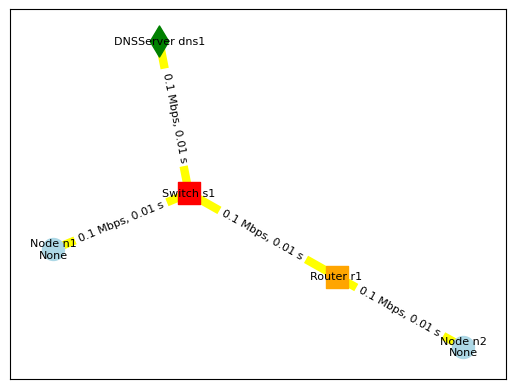

Time: 0.01 Node: r1, Event: dropped BPDU, Packet: 0209592b-2b46-4a6f-bdd6-fbfaa39da91f, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: dns1, Event: dropped, Packet: 581ec8cf-6b26-4de8-be8f-c4bfbc636f53, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r1, Event: dropped BPDU, Packet: 100a6561-0616-4fd0-917f-0b18093546a7, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0836738852644632 Node: s1, Event: received, Packet: 2928e975-58fa-4b6b-93cc-e2218db9af96, Src: 192.168.1.254, Dst: 224.0.0.5
Time: 0.4212285835156132 Node: s1, Event: received, Packet: 27f64911-cad6-482f-85f9-c86390caf701, Src: 192.168.1.254/24, Dst: 224.0.0.5
Time: 1.0 Node: n1, Event: DNS query, Packet: 0813776d-d817-4aa5-afcd-59023f060b39, Src: 192.168.1.1/24, Dst: 192.168.1.200/24
Time: 1.01 Node: s1, Event: received, Packet: 0813776d-d817-4aa5-afcd-59023f060b39, Src: 192.168.1.1/24, Dst: 192.168.1.200/24
Time: 1.01 Node: s1, Event: broadcast, Packet: 0813776d-d817-4aa5-afcd-59023f060b39, Src: 192.168.1.1/24, Dst: 192.

In [1]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec8b.NetworkEventScheduler import NetworkEventScheduler
from sec8b.Node import Node
from sec8b.Switch import Switch
from sec8b.Router import Router
from sec8b.DNSServer import DNSServer
from sec8b.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.1/24", dns_server="192.168.1.200/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.11/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# 通信アプリケーションの設定
node1.start_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_url_to_ip_mapping()
router1.print_arp_table()
router1.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


### 演習課題1: ARPログの抽出

#### 目的
ARPによるMACアドレス解決の手順をトレースし、その仕組みを理解する。

#### 課題の概要
任意のネットワークトポロジでトラフィックを設定し、パケット通信を行います。
そしてNetworkEventSchedulerのログから、ARP関連のログを抽出し、まとめてみましょう。
特に、ARPによってどのようにアドレス解決が行われるかを説明してください。

### 演習課題2: DNSレコードの設定

#### 目的
DNSサーバにドメイン名とIPアドレスの対応関係を設定する方法を理解し、ネットワーク上での名前解決プロセスとトラフィックの流れを実際に体験する。

#### 課題
DNSサーバに対して、以下のドメイン名とIPアドレスの対応関係を設定してください。
この設定は、ドメイン名をIPアドレスに解決する際に使用されます。

```
www.example.com -> 192.168.1.1
service.example.net -> 192.168.1.2
api.example.org -> 192.168.1.3
```

### 演習課題3: URLによる通信の設定

#### 目的
DNSレコードに基づいてトラフィックを生成するアプリケーションの設定方法を学ぶ。
DNSサーバに対するIPアドレスの問い合わせの流れを追って理解する。

#### 課題
演習課題2で設定したDNSレコードに基づいて、トラフィックを設定してみましょう。
またNetworkEventSchedulerのログから、DNS関連のログを抽出し、まとめてみましょう。


## 本章のまとめ

本章では、通信に先立ってMACアドレスやIPアドレスを問い合わせるアドレス解決の仕組みについて学習しました。
具体的には、IPアドレスからMACアドレスを調べるARPを実装し、その処理手順を確認しました。
ARPを用いることで、MACアドレスを意識せずに通信を行うことができます。
さらに、ドメイン名をIPアドレスに変換するDNSの仕組みを学習しました。
DNSのおかげで、数字の羅列であるIPアドレスではなく、可読性の高いURLを用いてインターネットを利用できています。
私たちの日常生活では、このようなアドレス解決のプロトコルによって、MACアドレスやIPアドレスを意識せずに通信を行っているわけです。
